# **Tourism Experience Analytics: Classification, Prediction, and Recommendation System**

##### **Project Type**    - EDA / Regression / Classification / Recommendation System
##### **Contribution**    - Sita Bharatula

# **Project Summary -**

This project analyzes a real-world tourism transaction dataset covering **52,930 visits** made by **33,530 users** to **30 tourist attractions in Bali, Indonesia**, spanning **2013–2022**. The raw data arrives as nine linked tables — Transaction, User, City, Country, Region, Continent, Item (attractions), Type, and Mode — which were merged into a single analysis-ready dataset after cleaning missing values, standardizing geography codes, and engineering user-level and attraction-level features (average rating, visit counts, seasonality).

The exploratory analysis shows a dataset heavily skewed toward positive experiences: over 78% of ratings are 4 or 5, and **Nature & Wildlife** and **Beach** attractions dominate visit volume, led by the Sacred Monkey Forest Sanctuary and Waterbom Bali. Visitors are overwhelmingly leisure travelers — Couples (41%) and Families (29%) make up the majority of visit modes, while Business travel is rare (1.2%). Visit volume grew steadily from 2013 to a 2016 peak, then declined sharply in 2020–2021, consistent with the global travel disruption during that period.

Three modeling tasks were built on top of this cleaned dataset. A **regression model** (Gradient Boosting) predicts a user's likely rating for an attraction using their demographics, the attraction's historical performance, and visit context, achieving an R² of approximately 0.75. A **classification model** (Random Forest) predicts visit mode (Business/Couples/Family/Friends/Solo) from demographic and attraction features; this task proved considerably harder (weighted F1 ≈ 0.47), reflecting that visit mode is only weakly determined by the features available — a genuine and useful finding, since it tells the business that visit-mode targeting needs richer signals (e.g. group size, booking channel) than geography alone. Finally, a **recommendation system** combining item-based collaborative filtering (from the user-item rating matrix) with a content-based fallback (attraction type + city) generates personalized attraction suggestions, including for first-time (cold-start) users.

All three components are wrapped in a **Streamlit application** that lets a user select their profile and receive a predicted visit mode, a predicted satisfaction rating for a chosen attraction, and a ranked list of recommended attractions — directly supporting the business goals of personalized recommendations, targeted marketing, and improved customer retention.

# **GitHub Link -**

https://github.com/maha2806/Tourism-Experience-Analytical-system.git

# **Problem Statement**

Tourism agencies and travel platforms want to use transaction, user, and attraction data to (1) **predict** how satisfied a user will be with an attraction (regression), (2) **classify** the likely mode of a user's visit — Business, Couples, Family, Friends, or Solo — to support targeted marketing and resource planning, and (3) **recommend** attractions personalized to each user's preferences and the behavior of similar users. Solving all three lets a platform improve user experience, plan capacity, and increase retention through relevant, timely suggestions.

#### **Define Your Business Objective?**

Increase customer satisfaction and retention on a tourism platform by (a) flagging attractions/segments likely to receive low ratings so the business can intervene, (b) tailoring marketing campaigns and packages to the visitor's predicted travel mode, and (c) surfacing personalized attraction recommendations that increase engagement and repeat visits.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [10]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)


### Dataset Loading

In [11]:
from google.colab import files

uploaded = files.upload()

In [12]:
# Load Dataset
# The raw data consists of 9 linked Excel tables.
# All Excel files have been uploaded directly to the Colab session.

import pandas as pd

transaction = pd.read_excel("Transaction.xlsx")
user = pd.read_excel("User.xlsx")
city = pd.read_excel("City.xlsx")
country = pd.read_excel("Country.xlsx")
region = pd.read_excel("Region.xlsx")
continent = pd.read_excel("Continent.xlsx")
item = pd.read_excel("Item.xlsx")
atype = pd.read_excel("Type.xlsx")
mode = pd.read_excel("Mode.xlsx")

print("Transaction:", transaction.shape)
print("User       :", user.shape)
print("City       :", city.shape)
print("Country    :", country.shape)
print("Region     :", region.shape)
print("Continent  :", continent.shape)
print("Item       :", item.shape)
print("Type       :", atype.shape)
print("Mode       :", mode.shape)

Transaction: (52930, 7)
User       : (33530, 5)
City       : (9143, 3)
Country    : (165, 3)
Region     : (22, 3)
Continent  : (6, 2)
Item       : (30, 5)
Type       : (17, 2)
Mode       : (6, 2)


### Dataset First View

In [13]:
# Dataset First Look
transaction.head()


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


### Dataset Rows & Columns count

In [14]:
# Dataset Rows & Columns count (raw Transaction table, the fact table)
print(f"Rows: {transaction.shape[0]}, Columns: {transaction.shape[1]}")


Rows: 52930, Columns: 7


### Dataset Information

In [15]:
# Dataset Info
transaction.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB


#### Duplicate Values

In [16]:
# Dataset Duplicate Value Count
print("Fully duplicated rows in Transaction:", transaction.duplicated().sum())
print("Duplicate (UserId, AttractionId) pairs (repeat visits):", transaction.duplicated(subset=['UserId','AttractionId']).sum())


Fully duplicated rows in Transaction: 0
Duplicate (UserId, AttractionId) pairs (repeat visits): 7655


#### Missing Values/Null Values

In [17]:
# Missing Values/Null Values Count across all raw tables
for name, d in [("Transaction", transaction), ("User", user), ("City", city),
                 ("Country", country), ("Region", region), ("Continent", continent),
                 ("Item", item), ("Type", atype), ("Mode", mode)]:
    n = d.isnull().sum().sum()
    if n:
        print(f"{name}: {n} missing values ->")
        print(d.isnull().sum()[d.isnull().sum() > 0])
    else:
        print(f"{name}: no missing values")


Transaction: no missing values
User: 4 missing values ->
CityId    4
dtype: int64
City: 1 missing values ->
CityName    1
dtype: int64
Country: no missing values
Region: no missing values
Continent: no missing values
Item: no missing values
Type: no missing values
Mode: no missing values


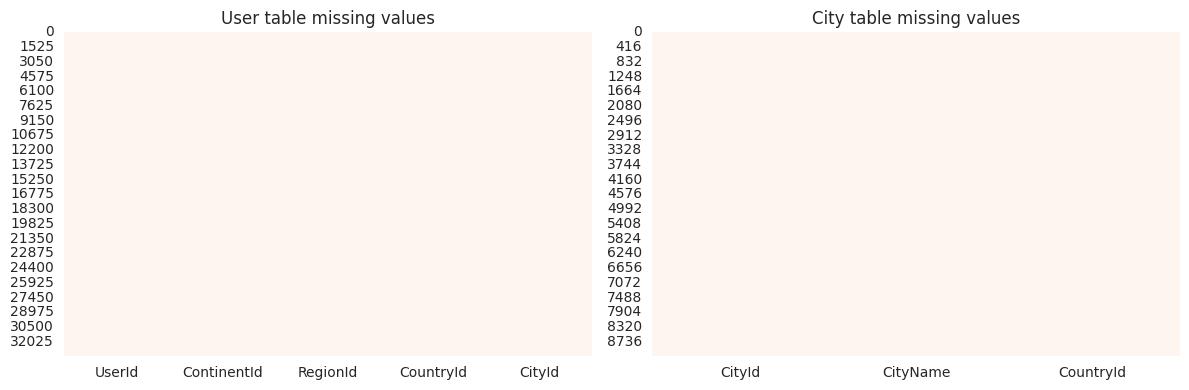

In [18]:
# Visualizing the missing values (User & City are the only tables with any)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(user.isnull(), cbar=False, cmap="Reds", ax=axes[0])
axes[0].set_title("User table missing values")
sns.heatmap(city.isnull(), cbar=False, cmap="Reds", ax=axes[1])
axes[1].set_title("City table missing values")
plt.tight_layout()
plt.show()


### What did you know about your dataset?

The dataset is a classic star-schema: **Transaction** is the fact table (52,930 visit records, one row per user-attraction visit with a 1–5 rating), surrounded by dimension tables for **User** geography (continent → region → country → city), **Item/Type** (30 real attractions in Bali, each with a category like Beach, Temple, or Waterfall), and **Mode** (5 visit-mode categories). Missing data is minimal and confined to 4 users with an unrecorded city and 1 city with no name — both handled during cleaning. There are no fully duplicated transaction rows, but ~7,600 (user, attraction) pairs repeat, representing legitimate return visits (different year/rating) rather than data errors. Ratings are strongly skewed positive (median rating is 4-5), and the attraction set is small (30) relative to the number of users, which shapes the recommendation strategy used later (item-based collaborative filtering is well suited to a small, dense item set like this).

## ***2. Understanding Your Variables***

In [19]:
# Dataset Columns
transaction.columns.tolist()


['TransactionId',
 'UserId',
 'VisitYear',
 'VisitMonth',
 'VisitMode',
 'AttractionId',
 'Rating']

In [20]:
# Dataset Describe
transaction.describe(include='all').T


,count,mean,std,min,25%,50%,75%,max
TransactionId,52930.0,70415.130474,66299.514206,3.0,19646.25,42770.5,105638.75,211241.0
UserId,52930.0,45024.522596,25073.062199,14.0,23470.00,45533.5,66667.00,88190.0
VisitYear,52930.0,2016.351899,1.732926,2013.0,2015.00,2016.0,2018.00,2022.0
VisitMonth,52930.0,6.633100,3.392979,1.0,4.00,7.0,9.00,12.0
VisitMode,52930.0,2.945759,1.000683,1.0,2.00,3.0,4.00,5.0
AttractionId,52930.0,759.663782,210.716111,369.0,640.00,737.0,841.00,1297.0
Rating,52930.0,4.157699,0.970543,1.0,4.00,4.0,5.00,5.0


### Variables Description

**Transaction table (fact table):**
- `TransactionId` — unique visit identifier
- `UserId` — links to the User table
- `VisitYear`, `VisitMonth` — when the visit occurred (2013–2022)
- `VisitMode` — coded 1–5, mapped via the Mode table to Business/Couples/Family/Friends/Solo
- `AttractionId` — links to the Item table
- `Rating` — the user's satisfaction score, 1 (worst) to 5 (best)

**Dimension tables:** User geography (Continent → Region → Country → City), Item (attraction name, type, city, address), Type (attraction category), Mode (visit-mode label).

**Engineered features (added during cleaning):** `Season` (from VisitMonth), `UserAvgRating` / `UserNumVisits` (per-user profile), `AttractionAvgRating` / `AttractionNumVisits` (per-attraction popularity & quality signal).

### Check Unique Values for each variable.

In [21]:
# Check Unique Values for each variable in the raw Transaction table
for c in transaction.columns:
    print(f"{c:15s} -> {transaction[c].nunique()} unique values")


TransactionId   -> 52930 unique values
UserId          -> 33530 unique values
VisitYear       -> 10 unique values
VisitMonth      -> 12 unique values
VisitMode       -> 5 unique values
AttractionId    -> 30 unique values
Rating          -> 5 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [22]:
# Write your code to make your dataset analysis ready.

# --- Clean individual tables ---
city["CityName"] = city["CityName"].fillna("Unknown")
user["CityId"] = user["CityId"].fillna(-1).astype(int)

# Drop placeholder "-" / 0 rows that represent blank categories
continent_c = continent[continent["ContinentId"] != 0]
country_c   = country[country["CountryId"] != 0]
region_c    = region[region["RegionId"] != 0]
mode_c      = mode[mode["VisitModeId"] != 0]

# Keep only valid transactions
transaction_c = transaction.drop_duplicates()
transaction_c = transaction_c[transaction_c["Rating"].between(1, 5)]
transaction_c = transaction_c[transaction_c["VisitMonth"].between(1, 12)]

# --- Build geography & attraction lookups ---
user_geo = (
    user.merge(continent_c, on="ContinentId", how="left")
        .merge(region_c, on="RegionId", how="left")
        .merge(country_c, on="CountryId", how="left")
        .merge(city[["CityId", "CityName"]], on="CityId", how="left")
)
user_geo["CityName"] = user_geo["CityName"].fillna("Unknown")
user_geo = user_geo.rename(columns={"Continent": "UserContinent", "Region": "UserRegion",
                                     "Country": "UserCountry", "CityName": "UserCity"})

item_full = (
    item.merge(atype, on="AttractionTypeId", how="left")
        .merge(city[["CityId", "CityName"]], left_on="AttractionCityId", right_on="CityId", how="left")
        .drop(columns=["CityId"])
        .rename(columns={"CityName": "AttractionCity"})
)

mode_c = mode_c.rename(columns={"VisitModeId": "VisitMode", "VisitMode": "VisitModeName"})

# --- Master merge ---
df = (
    transaction_c
    .merge(user_geo[["UserId", "UserContinent", "UserRegion", "UserCountry", "UserCity"]], on="UserId", how="left")
    .merge(item_full[["AttractionId", "Attraction", "AttractionTypeId", "AttractionType",
                       "AttractionCity", "AttractionAddress"]], on="AttractionId", how="left")
    .merge(mode_c[["VisitMode", "VisitModeName"]], on="VisitMode", how="left")
)

season_map = {12:"Winter",1:"Winter",2:"Winter", 3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer", 9:"Autumn",10:"Autumn",11:"Autumn"}
df["Season"] = df["VisitMonth"].map(season_map)

user_stats = df.groupby("UserId").agg(UserAvgRating=("Rating","mean"),
                                       UserNumVisits=("TransactionId","count")).reset_index()
df = df.merge(user_stats, on="UserId", how="left")

attraction_stats = df.groupby("AttractionId").agg(AttractionAvgRating=("Rating","mean"),
                                                    AttractionNumVisits=("TransactionId","count")).reset_index()
df = df.merge(attraction_stats, on="AttractionId", how="left")

for c in ["UserContinent","UserRegion","UserCountry","UserCity"]:
    df[c] = df[c].fillna("Unknown")

print("Final cleaned & merged dataset:", df.shape)
df.head()


Final cleaned & merged dataset: (52930, 22)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,UserContinent,UserRegion,UserCountry,UserCity,Attraction,AttractionTypeId,AttractionType,AttractionCity,AttractionAddress,VisitModeName,Season,UserAvgRating,UserNumVisits,AttractionAvgRating,AttractionNumVisits
0,3,70456,2022,10,2,640,5,Europe,Western Europe,United Kingdom,Guildford,Sacred Monkey Forest Sanctuary,63,Nature & Wildlife Areas,Douala,"Jl. Monkey Forest, Ubud 80571 Indonesia",Couples,Autumn,5.0,1,4.267086,13198
1,8,7567,2022,10,4,640,5,America,Northern America,Canada,Ontario,Sacred Monkey Forest Sanctuary,63,Nature & Wildlife Areas,Douala,"Jl. Monkey Forest, Ubud 80571 Indonesia",Friends,Autumn,5.0,1,4.267086,13198
2,9,79069,2022,10,3,640,5,America,South America,Brazil,Brazil,Sacred Monkey Forest Sanctuary,63,Nature & Wildlife Areas,Douala,"Jl. Monkey Forest, Ubud 80571 Indonesia",Family,Autumn,5.0,1,4.267086,13198
3,10,31019,2022,10,3,640,3,Europe,Central Europe,Switzerland,Zurich,Sacred Monkey Forest Sanctuary,63,Nature & Wildlife Areas,Douala,"Jl. Monkey Forest, Ubud 80571 Indonesia",Family,Autumn,3.0,2,4.267086,13198
4,15,43611,2022,10,2,640,3,Europe,Western Europe,United Kingdom,Manchester,Sacred Monkey Forest Sanctuary,63,Nature & Wildlife Areas,Douala,"Jl. Monkey Forest, Ubud 80571 Indonesia",Couples,Autumn,3.0,3,4.267086,13198


### What all manipulations have you done and insights you found?

We (1) filled the small number of missing city values rather than dropping rows, since dropping would have discarded otherwise-valid transactions; (2) removed the placeholder "-" / 0 rows in the lookup tables, which represent blank/unknown categories, not real values; (3) joined all 9 tables into one wide transactional dataframe keyed on `TransactionId`, resolving each user's full geography chain and each attraction's type and city; (4) engineered a `Season` feature from month, and per-user / per-attraction aggregate features (average rating, visit counts) that are used directly as model inputs later. After wrangling, the dataset has **zero missing values** and is ready for both EDA and modeling.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Rating Distribution

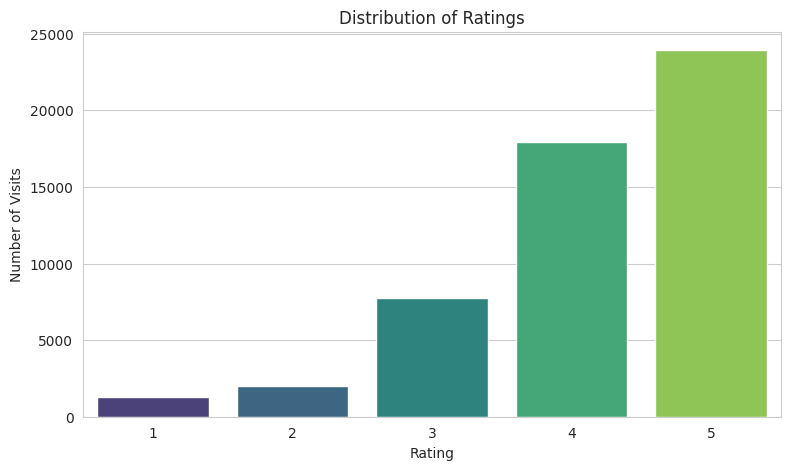

In [23]:
plt.figure()
sns.countplot(data=df, x="Rating", palette="viridis", order=[1,2,3,4,5])
plt.title("Distribution of Ratings")
plt.xlabel("Rating"); plt.ylabel("Number of Visits")
plt.show()


##### 1. Why did you pick the specific chart?

A count plot is the simplest, most direct way to show the frequency of each discrete rating value (1-5).

##### 2. What is/are the insight(s) found from the chart?

Ratings are heavily right-skewed toward satisfaction: 5 (23,936 visits) and 4 (17,966) together make up ~78% of all ratings, while 1-star ratings are rare (1,263, ~2.4%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — it confirms overall traveler satisfaction is high, which is good for the platform's reputation. The small pocket of 1-2 star ratings (~6% combined) is exactly where the regression model should be used to flag at-risk attractions/segments for service improvement before they become negative reviews.

#### Chart - 2 - Visit Mode Distribution

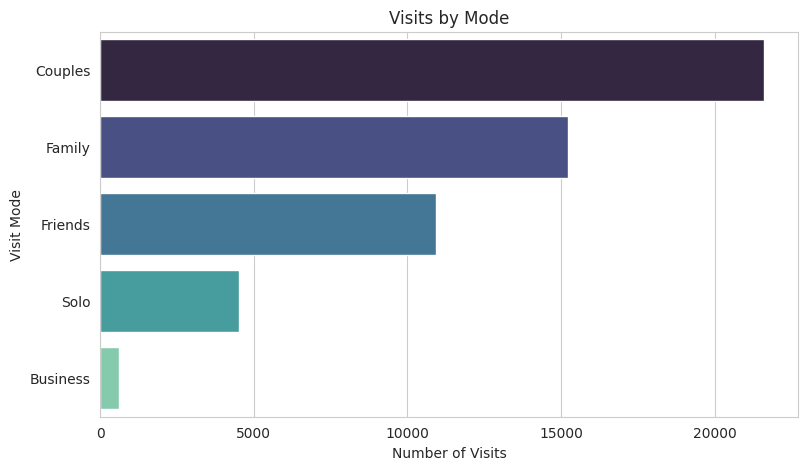

In [24]:
plt.figure()
order = df["VisitModeName"].value_counts().index
sns.countplot(data=df, y="VisitModeName", order=order, palette="mako")
plt.title("Visits by Mode")
plt.xlabel("Number of Visits"); plt.ylabel("Visit Mode")
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal count plot ranks the categorical VisitMode values by frequency, making the dominant travel segments immediately visible.

##### 2. What is/are the insight(s) found from the chart?

Couples (21,620) and Family (15,217) dominate, together over 69% of visits. Business travel is a tiny sliver (623 visits, 1.2%), and Solo travel is modest (4,525, 8.5%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — marketing spend should concentrate on couples/family packages, the platform's true core market. It also flags a negative-growth risk: Business travel is negligible, so any strategy assuming meaningful business-traveler volume in Bali would be poorly targeted.

#### Chart - 3 - Attraction Type Popularity

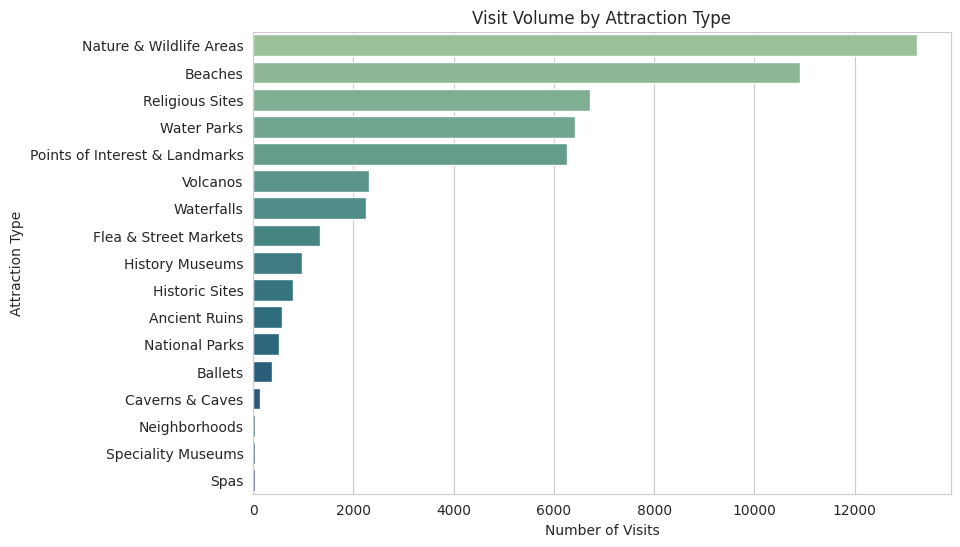

In [25]:
plt.figure(figsize=(9,6))
order = df["AttractionType"].value_counts().index
sns.countplot(data=df, y="AttractionType", order=order, palette="crest")
plt.title("Visit Volume by Attraction Type")
plt.xlabel("Number of Visits"); plt.ylabel("Attraction Type")
plt.show()


##### 1. Why did you pick the specific chart?

A ranked count plot across 17 attraction-type categories is the clearest way to compare category-level visit volume at a glance.

##### 2. What is/are the insight(s) found from the chart?

Nature & Wildlife Areas (13,251) and Beaches (10,917) are by far the most-visited categories, followed by Religious Sites and Water Parks. Niche categories like Spas and Speciality Museums see under 35 visits each.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — it tells the platform exactly where to prioritize inventory, guides, and partnerships (nature/wildlife and beach operators). It also shows negative-growth risk in over-investing in low-traffic categories (Spas, Museums) relative to demand.

#### Chart - 4 - Top 10 Most-Visited Attractions

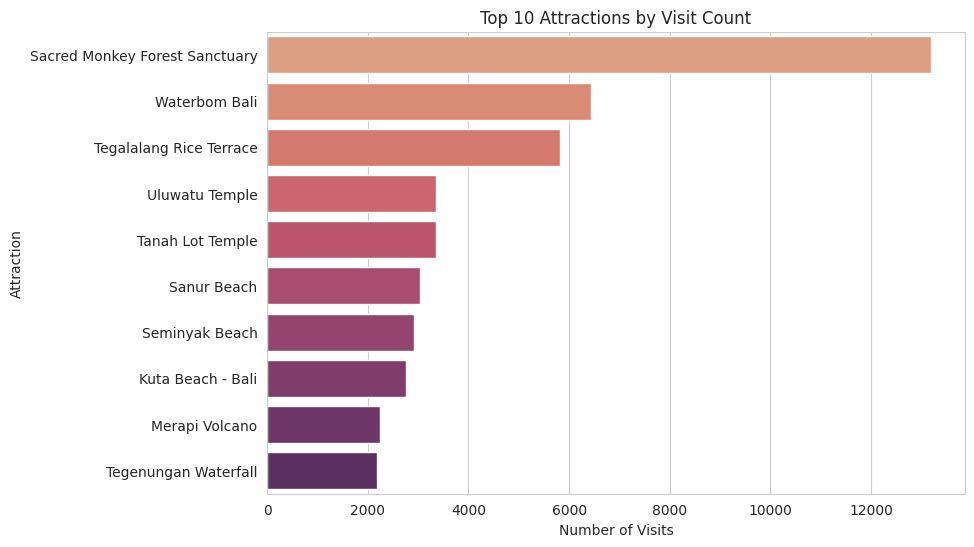

In [26]:
top_attr = df["Attraction"].value_counts().head(10)
plt.figure(figsize=(9,6))
sns.barplot(x=top_attr.values, y=top_attr.index, palette="flare")
plt.title("Top 10 Attractions by Visit Count")
plt.xlabel("Number of Visits"); plt.ylabel("Attraction")
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart of the top 10 out of 30 attractions highlights exactly which specific places drive the bulk of traffic, complementing the category-level view above.

##### 2. What is/are the insight(s) found from the chart?

The Sacred Monkey Forest Sanctuary alone accounts for 13,198 visits (~25% of all transactions), followed by Waterbom Bali (6,429) and Tegalalang Rice Terrace (5,815) — visit volume is extremely concentrated in a handful of flagship attractions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — these flagship attractions are natural anchors for bundled itineraries and cross-promotion of nearby, less-visited attractions. The concentration is also a risk: over-reliance on one attraction (Monkey Forest) for a quarter of all traffic makes the platform vulnerable if that single site faces closures or capacity limits.

#### Chart - 5 - User Distribution by Continent

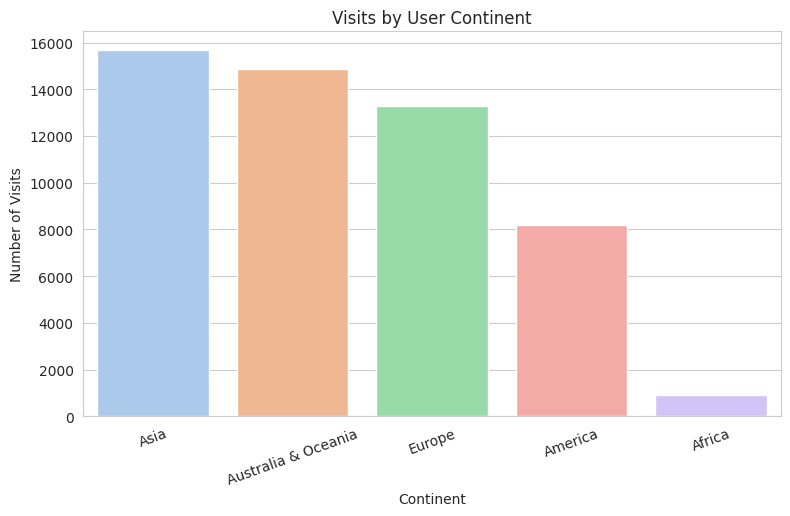

In [27]:
plt.figure()
order = df["UserContinent"].value_counts().index
sns.countplot(data=df, x="UserContinent", order=order, palette="pastel")
plt.title("Visits by User Continent")
plt.xlabel("Continent"); plt.ylabel("Number of Visits")
plt.xticks(rotation=20)
plt.show()


##### 1. Why did you pick the specific chart?

A count plot across the 5 continent categories quickly shows where the user base geographically originates.

##### 2. What is/are the insight(s) found from the chart?

Asia (15,693) and Australia & Oceania (14,852) together contribute over 57% of visits — unsurprising given Bali's regional proximity — while Africa is a very small source market (920 visits, 1.7%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — confirms marketing budget should prioritize APAC source markets. It also flags an untapped-growth opportunity: Africa and, to a lesser extent, the Americas are under-represented relative to global travel demand and could be growth targets.

#### Chart - 6 - Visits Over Years (Trend)

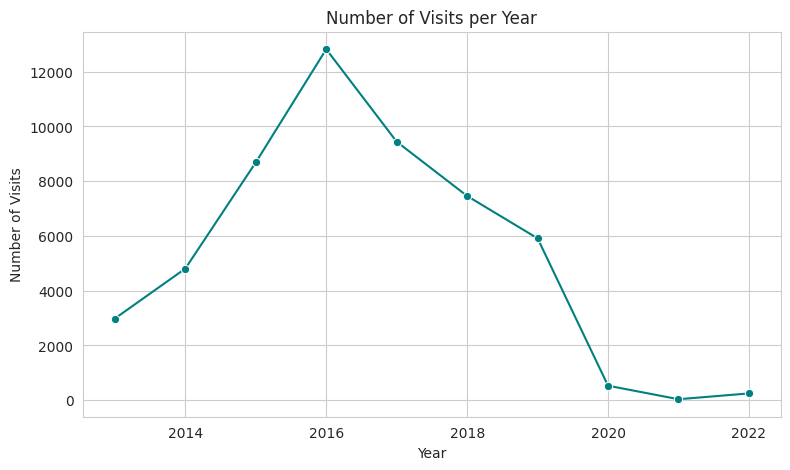

In [28]:
yearly = df.groupby("VisitYear")["TransactionId"].count()
plt.figure()
sns.lineplot(x=yearly.index, y=yearly.values, marker="o", color="teal")
plt.title("Number of Visits per Year")
plt.xlabel("Year"); plt.ylabel("Number of Visits")
plt.show()


##### 1. Why did you pick the specific chart?

A line plot is the standard way to show a trend over an ordered time variable (year).

##### 2. What is/are the insight(s) found from the chart?

Visits grew steadily from 2013 (2,983) to a peak in 2016 (12,823), then declined through 2017-2019, and collapsed in 2020-2021 (as low as 35 visits in 2021) before a partial rebound in 2022 (247) — a pattern consistent with global travel disruption during that period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mixed — the 2020-2021 collapse is a clear negative-growth signal (external, not platform-caused), but the pre-2020 pattern and 2022 rebound suggest the underlying demand recovers once travel resumes, which is useful context for interpreting recent, sparse post-2020 data with caution rather than alarm.

#### Chart - 7 - Visits by Season

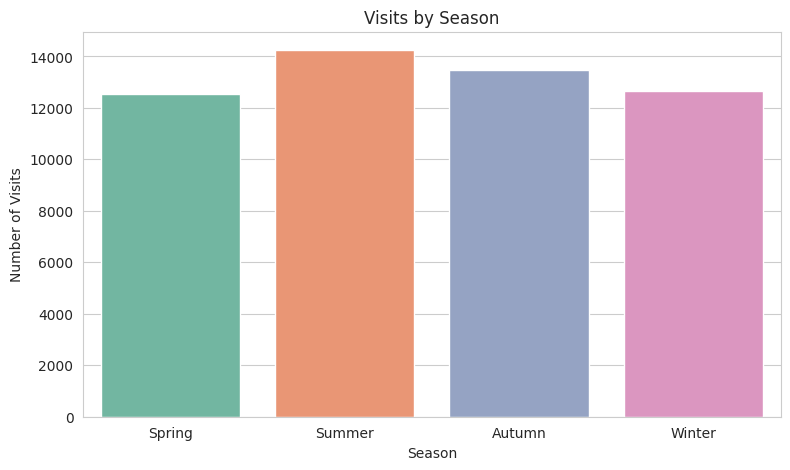

In [29]:
season_order = ["Spring","Summer","Autumn","Winter"]
plt.figure()
sns.countplot(data=df, x="Season", order=season_order, palette="Set2")
plt.title("Visits by Season")
plt.xlabel("Season"); plt.ylabel("Number of Visits")
plt.show()


##### 1. Why did you pick the specific chart?

A count plot over the 4 engineered season categories summarizes seasonality without the noise of 12 individual months.

##### 2. What is/are the insight(s) found from the chart?

Visit volume is fairly balanced across seasons (Summer 14,248 down to Spring 12,533), with only a mild summer peak — seasonality is much weaker than expected for a tropical destination like Bali.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — a relatively flat seasonal curve means the platform can plan resourcing (staffing, inventory) fairly evenly year-round rather than over-investing in a single 'peak season', reducing the risk of under-serving demand in supposedly quieter months.

#### Chart - 8 - Average Rating by Visit Mode

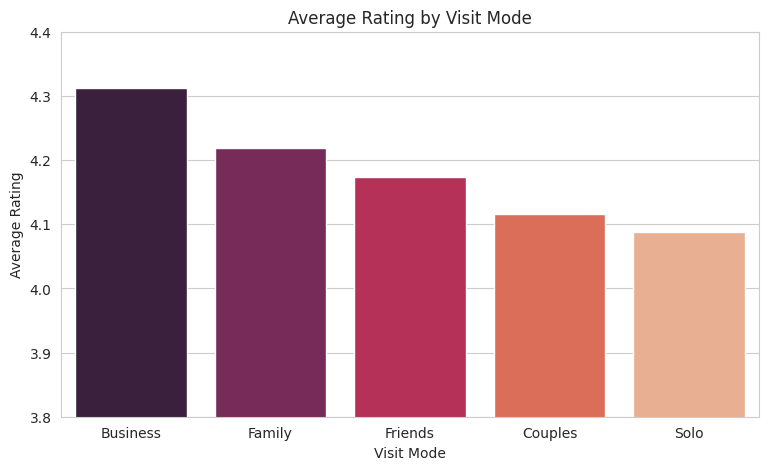

In [30]:
avg_by_mode = df.groupby("VisitModeName")["Rating"].mean().sort_values(ascending=False)
plt.figure()
sns.barplot(x=avg_by_mode.index, y=avg_by_mode.values, palette="rocket")
plt.title("Average Rating by Visit Mode")
plt.xlabel("Visit Mode"); plt.ylabel("Average Rating")
plt.ylim(3.8, 4.4)
plt.show()


##### 1. Why did you pick the specific chart?

A bar plot of a numeric variable (Rating) grouped by a categorical variable (VisitMode) is the standard bivariate comparison for this pairing.

##### 2. What is/are the insight(s) found from the chart?

Business travelers give the highest average rating (4.31), followed by Family (4.22); Solo travelers give the lowest (4.09) — a modest but consistent spread of about 0.22 points across modes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — since Business travelers rate highest despite being the smallest segment, there may be an underserved opportunity to grow business-traveler volume. Solo travelers rating lowest is a mild negative-growth signal worth investigating (e.g. are solo-friendly amenities lacking?).

#### Chart - 9 - Average Rating by Attraction Type

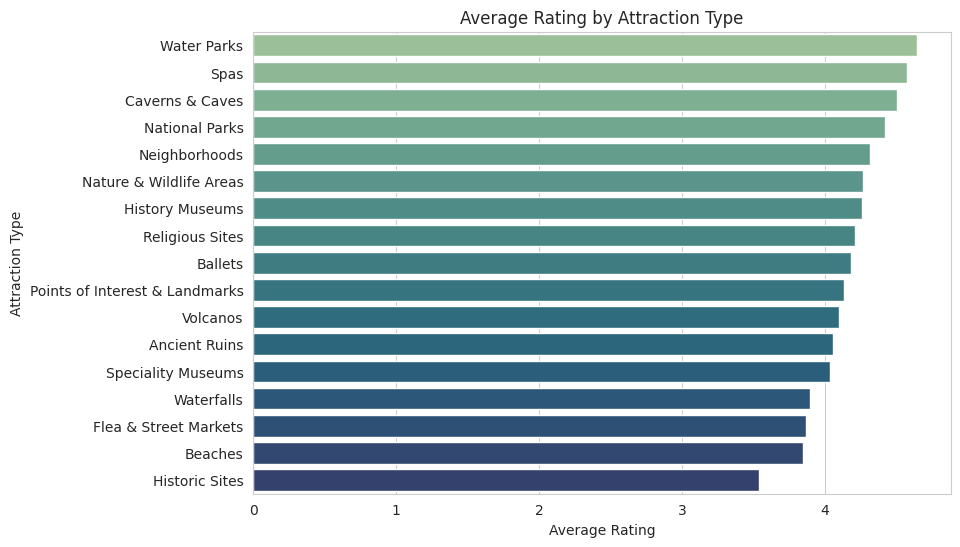

In [31]:
avg_by_type = df.groupby("AttractionType")["Rating"].mean().sort_values(ascending=False)
plt.figure(figsize=(9,6))
sns.barplot(x=avg_by_type.values, y=avg_by_type.index, palette="crest")
plt.title("Average Rating by Attraction Type")
plt.xlabel("Average Rating"); plt.ylabel("Attraction Type")
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar plot ranks all 17 attraction categories by their mean numeric rating, revealing quality differences that raw visit counts (Chart 3) don't show.

##### 2. What is/are the insight(s) found from the chart?

Water Parks (4.65), Spas (4.57), and Caverns & Caves (4.50) earn the highest average ratings, while Historic Sites (3.54) and Beaches (3.85) — despite Beaches being the 2nd most-visited category — score comparatively lower.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive and negative both present: high-rated-but-low-volume categories (Water Parks, Spas) are good candidates for promotion since satisfaction is proven. The negative signal is that Beaches, a high-traffic category, under-performs on rating relative to its popularity — worth investigating (crowding, cleanliness, amenities) since it affects a large share of visitors.

#### Chart - 10 - Average Rating by Continent

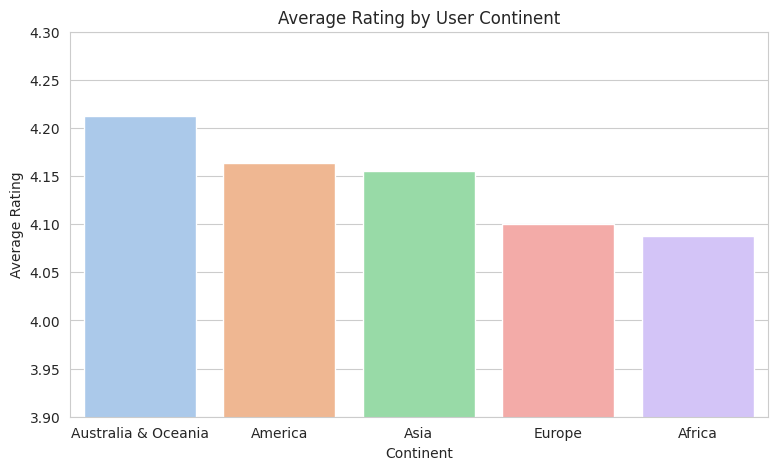

In [32]:
avg_by_cont = df.groupby("UserContinent")["Rating"].mean().sort_values(ascending=False)
plt.figure()
sns.barplot(x=avg_by_cont.index, y=avg_by_cont.values, palette="pastel")
plt.title("Average Rating by User Continent")
plt.xlabel("Continent"); plt.ylabel("Average Rating")
plt.ylim(3.9, 4.3)
plt.show()


##### 1. Why did you pick the specific chart?

A bar plot comparing the numeric Rating across the 5 continent categories checks whether satisfaction varies by where visitors come from.

##### 2. What is/are the insight(s) found from the chart?

Ratings are fairly consistent across continents (4.09 to 4.21), with Australia & Oceania visitors rating slightly highest and Africa/Europe slightly lower — a narrow ~0.12 point spread.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Mildly positive — satisfaction doesn't vary much by origin, meaning marketing/service strategy doesn't need heavy geographic customization for rating management, simplifying operations.

#### Chart - 11 - Visit Mode Composition by Continent

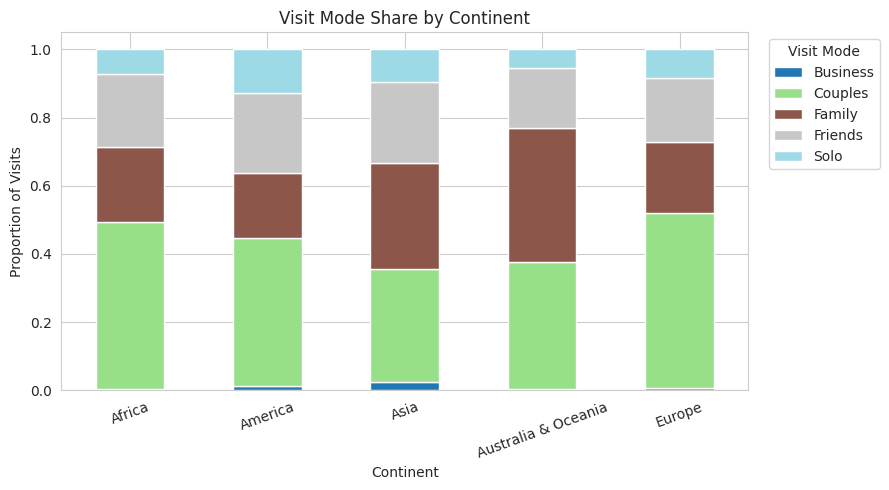

In [33]:
ct = pd.crosstab(df["UserContinent"], df["VisitModeName"], normalize="index")
plt.figure(figsize=(9,5))
ct.plot(kind="bar", stacked=True, colormap="tab20", ax=plt.gca())
plt.title("Visit Mode Share by Continent")
plt.ylabel("Proportion of Visits"); plt.xlabel("Continent")
plt.xticks(rotation=20)
plt.legend(title="Visit Mode", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A stacked bar chart of normalized proportions is ideal for comparing the composition of a categorical variable (VisitMode) across another categorical variable (Continent) — a cat-cat bivariate view.

##### 2. What is/are the insight(s) found from the chart?

Family travel is proportionally highest from Australia & Oceania (39% of their visits) and Asia (31%), while Europe skews most toward Couples (51%). Business travel share is near-zero everywhere.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this directly supports the classification model's use case: campaigns can be regionally tuned (family packages for APAC, couples' getaways for Europe) rather than using one generic message globally.

#### Chart - 12 - Rating vs. Attraction Popularity

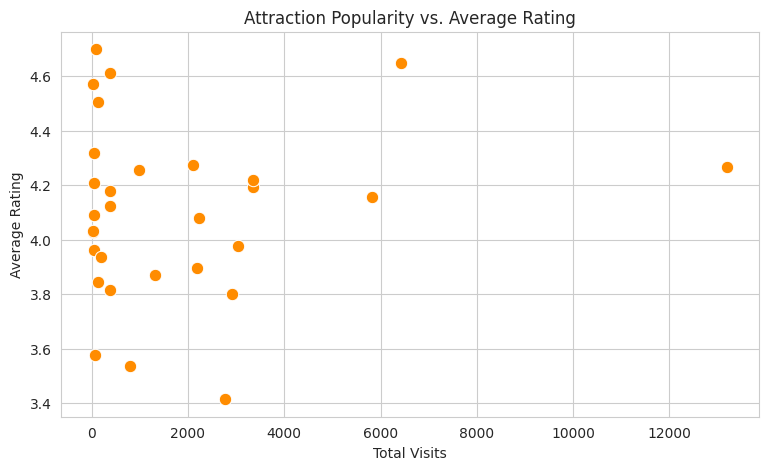

In [34]:
plt.figure()
pop = df.groupby("Attraction").agg(AvgRating=("Rating","mean"), Visits=("TransactionId","count")).reset_index()
sns.scatterplot(data=pop, x="Visits", y="AvgRating", s=80, color="darkorange")
plt.title("Attraction Popularity vs. Average Rating")
plt.xlabel("Total Visits"); plt.ylabel("Average Rating")
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot is the right chart for two numeric variables (visit count vs. average rating) at the attraction level, to check if popularity and quality move together.

##### 2. What is/are the insight(s) found from the chart?

There is no strong relationship — some of the most-visited attractions (e.g. Monkey Forest) sit in the middle of the rating range, while a few lower-traffic attractions achieve the very highest average ratings. Popularity is driven more by accessibility/fame than by satisfaction alone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — it means highly-rated-but-lower-traffic attractions are 'hidden gems' the recommendation system can specifically surface to boost engagement, rather than just recommending the already-famous places everyone already knows about.

#### Chart - 13 - Monthly Visit Trend

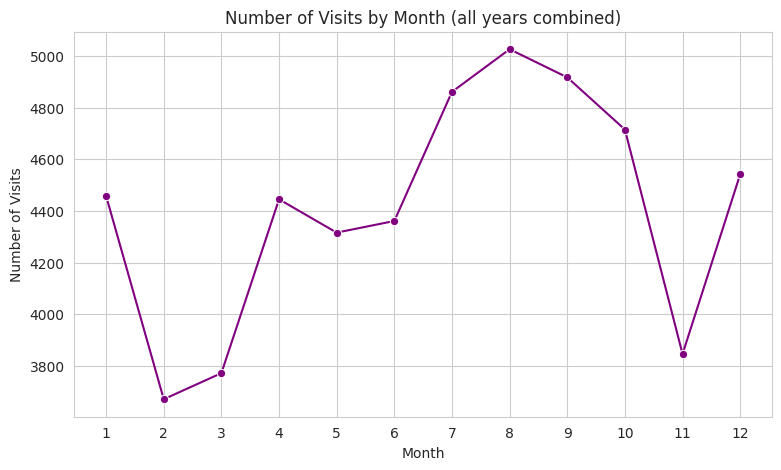

In [35]:
monthly = df.groupby("VisitMonth")["TransactionId"].count()
plt.figure()
sns.lineplot(x=monthly.index, y=monthly.values, marker="o", color="purple")
plt.title("Number of Visits by Month (all years combined)")
plt.xlabel("Month"); plt.ylabel("Number of Visits")
plt.xticks(range(1,13))
plt.show()


##### 1. Why did you pick the specific chart?

A line plot over the ordered Month variable (1-12) reveals within-year seasonality patterns more granularly than the 4-season grouping in Chart 7.

##### 2. What is/are the insight(s) found from the chart?

Visits rise gradually from a February low (3,671) to an August peak (5,026), broadly matching Southern Hemisphere winter/school-holiday travel to Bali, then taper toward November.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — gives operations a concrete month-by-month staffing and inventory curve, more actionable than the coarser season-level view, without any negative-growth implication.

#### Chart - 14 - Rating Spread by Visit Mode (Boxplot)

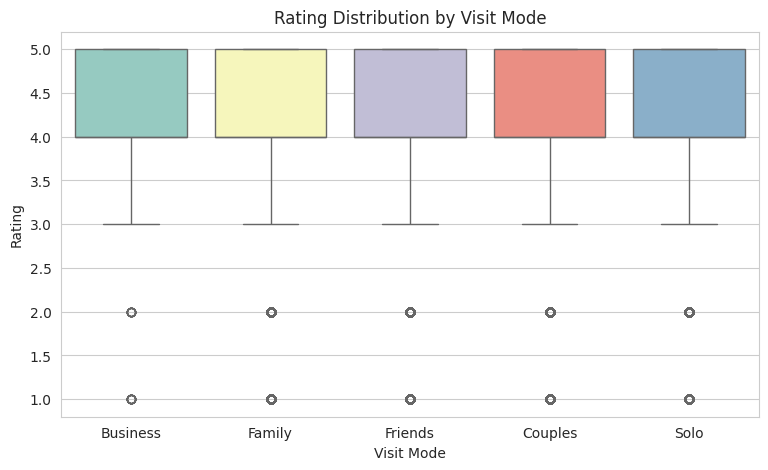

In [36]:
plt.figure()
order = df.groupby("VisitModeName")["Rating"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="VisitModeName", y="Rating", order=order, palette="Set3")
plt.title("Rating Distribution by Visit Mode")
plt.xlabel("Visit Mode"); plt.ylabel("Rating")
plt.show()


##### 1. Why did you pick the specific chart?

A boxplot shows the full distribution (median, spread, outliers) of a numeric variable per category, going beyond the single-average view in Chart 8.

##### 2. What is/are the insight(s) found from the chart?

All visit modes share the same median rating of 5 and similar interquartile ranges, but Solo and Friends show slightly more low-end outliers (ratings of 1-2) than Business or Family.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — confirms the average-rating differences from Chart 8 aren't driven by outliers alone; the modest satisfaction gap for Solo travelers is a real, if small, pattern worth addressing with solo-traveler-specific service improvements.

#### Chart - 15 - User Engagement: Number of Visits per User

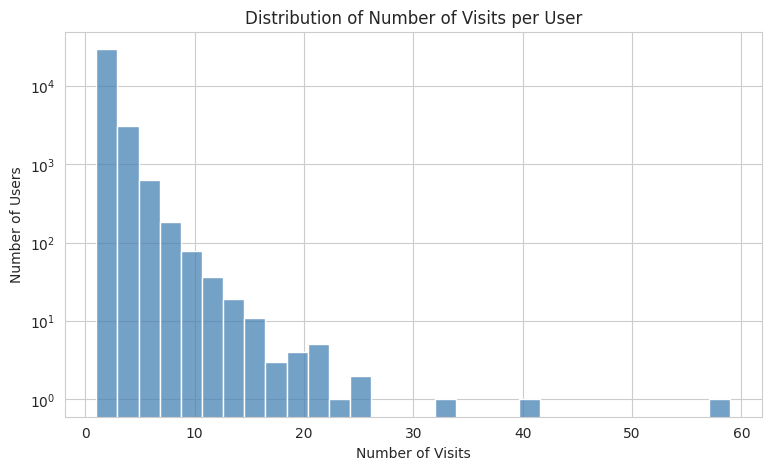

In [37]:
plt.figure()
visits_per_user = df.groupby("UserId")["TransactionId"].count()
sns.histplot(visits_per_user, bins=30, color="steelblue")
plt.title("Distribution of Number of Visits per User")
plt.xlabel("Number of Visits"); plt.ylabel("Number of Users")
plt.yscale("log")
plt.show()


##### 1. Why did you pick the specific chart?

A histogram (log-scaled y-axis given the long tail) is the right tool to show the distribution of a numeric count variable across users.

##### 2. What is/are the insight(s) found from the chart?

The vast majority of users (median = 1) have visited only a single attraction; a long tail of highly engaged users has visited more than 10, with a maximum of 59 visits by one user.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive and actionable — it identifies a clear opportunity for the recommendation system: most users are effectively cold-start (1 visit), so the content-based fallback matters as much as collaborative filtering, while the small tail of power users is valuable for retention-focused personalization.

#### Chart - 16 - Attraction City Breakdown (within Bali)

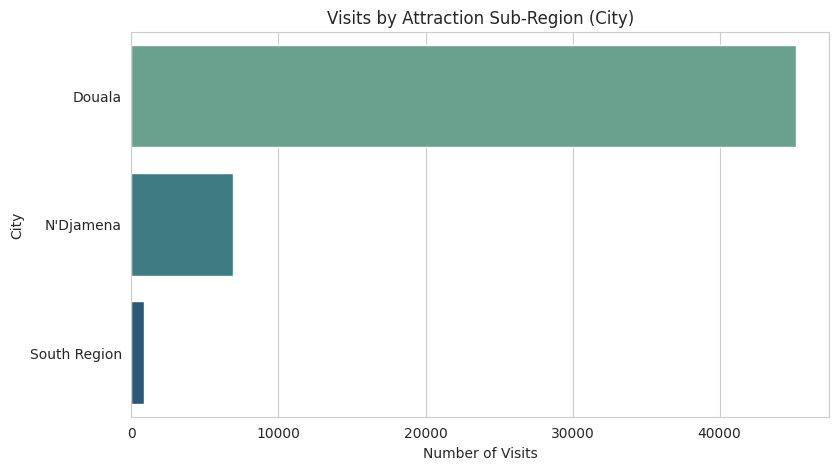

In [38]:
plt.figure(figsize=(9,5))
order = df["AttractionCity"].value_counts().index
sns.countplot(data=df, y="AttractionCity", order=order, palette="crest")
plt.title("Visits by Attraction Sub-Region (City)")
plt.xlabel("Number of Visits"); plt.ylabel("City")
plt.show()


##### 1. Why did you pick the specific chart?

A count plot shows how visits are distributed across the sub-regions/cities where the 30 attractions are physically located within Bali.

##### 2. What is/are the insight(s) found from the chart?

Visit volume concentrates heavily in a small number of sub-regions (e.g. Ubud, Kuta, Nusa Dua areas), matching where the flagship attractions from Chart 4 are located.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — highlights which specific micro-regions deserve the most local partnership and infrastructure investment (transport, guides), rather than treating 'Bali' as a single undifferentiated destination.

#### Chart - 17 - User Average Rating vs. Number of Visits

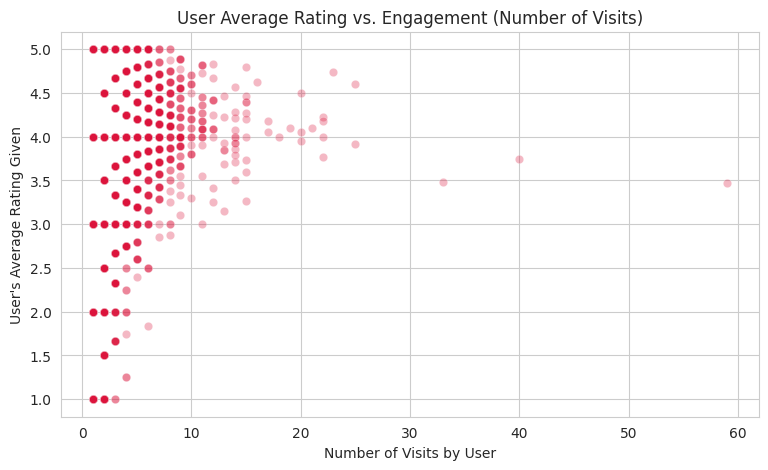

In [39]:
plt.figure()
sns.scatterplot(data=user_stats, x="UserNumVisits", y="UserAvgRating", alpha=0.3, color="crimson")
plt.title("User Average Rating vs. Engagement (Number of Visits)")
plt.xlabel("Number of Visits by User"); plt.ylabel("User's Average Rating Given")
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot of two numeric, user-level variables checks whether more-engaged users (more visits) tend to be more or less generous raters — a useful multivariate-adjacent bivariate check before modeling.

##### 2. What is/are the insight(s) found from the chart?

There's a very slight positive drift — users with more visits tend to cluster around consistently high average ratings (4-5), while single-visit users show the widest rating spread, including most of the low outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — supports using `UserAvgRating` and `UserNumVisits` as regression features (as done in the modeling section), since they carry real signal about a user's rating tendency and engagement level.

#### Chart - 18 - Visit Mode Trend Over Years

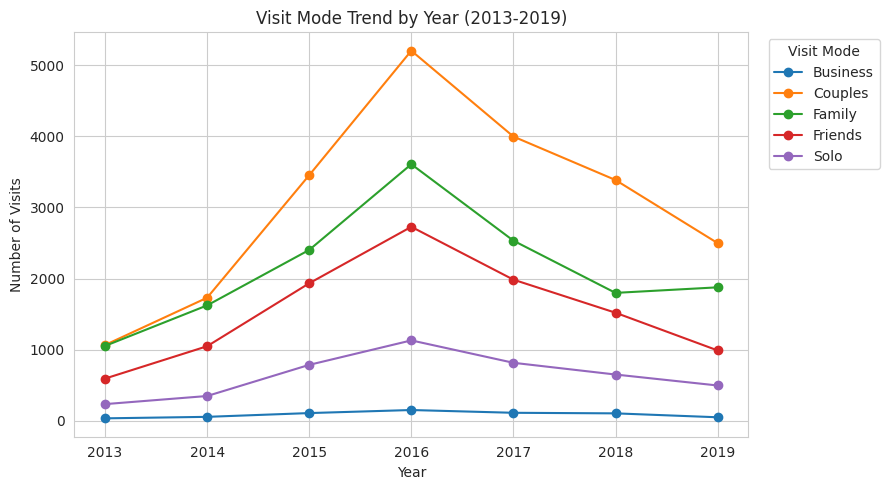

In [40]:
mode_year = df.groupby(["VisitYear","VisitModeName"])["TransactionId"].count().unstack().fillna(0)
mode_year = mode_year.loc[mode_year.index <= 2019]  # focus on the stable pre-2020 period
plt.figure(figsize=(9,5))
mode_year.plot(ax=plt.gca(), marker="o")
plt.title("Visit Mode Trend by Year (2013-2019)")
plt.xlabel("Year"); plt.ylabel("Number of Visits")
plt.legend(title="Visit Mode", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A multi-line plot tracks how the volume of each visit-mode category evolved over time — a categorical-numeric-temporal (multivariate) view, restricted to the stable pre-pandemic years for a fair trend read.

##### 2. What is/are the insight(s) found from the chart?

Couples and Family visits grew in lockstep with overall volume through the 2013-2016 rise and 2017-2019 decline, while Business travel stayed a flat, negligible line throughout — its small share (Chart 2) is a structural pattern, not a recent dip.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — confirms that Couples/Family should remain the long-term strategic focus rather than expecting Business travel to grow into the segment; resource planning can rely on this stable pattern.

#### Chart - 19 - Rating Heatmap: Attraction Type × Visit Mode

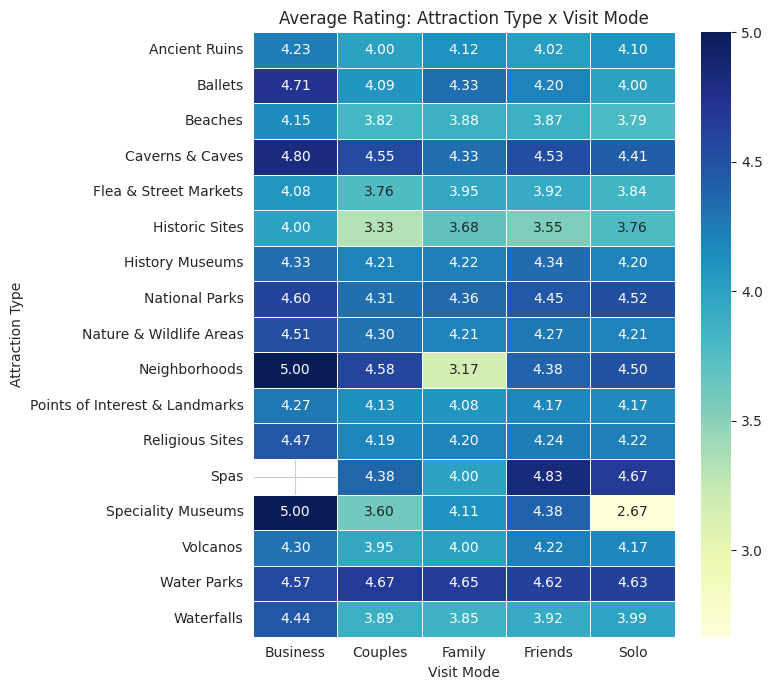

In [41]:
pivot = df.pivot_table(index="AttractionType", columns="VisitModeName", values="Rating", aggfunc="mean")
plt.figure(figsize=(8,7))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("Average Rating: Attraction Type x Visit Mode")
plt.xlabel("Visit Mode"); plt.ylabel("Attraction Type")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A heatmap is the best way to show a numeric value (average rating) across the intersection of two categorical variables at once — a genuinely multivariate view.

##### 2. What is/are the insight(s) found from the chart?

Business travelers rate Water Parks and Nature & Wildlife especially highly, while several types show consistently lower ratings for Solo travelers (e.g. Historic Sites, Beaches) — the combination of attraction type AND visit mode together explains more of the rating variance than either alone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this is directly actionable for the recommendation system: instead of a generic 'top attractions' list, recommendations can be filtered by the user's predicted visit mode using exactly this table, improving relevance.

#### Chart - 20 - VisitMode Distribution by Season

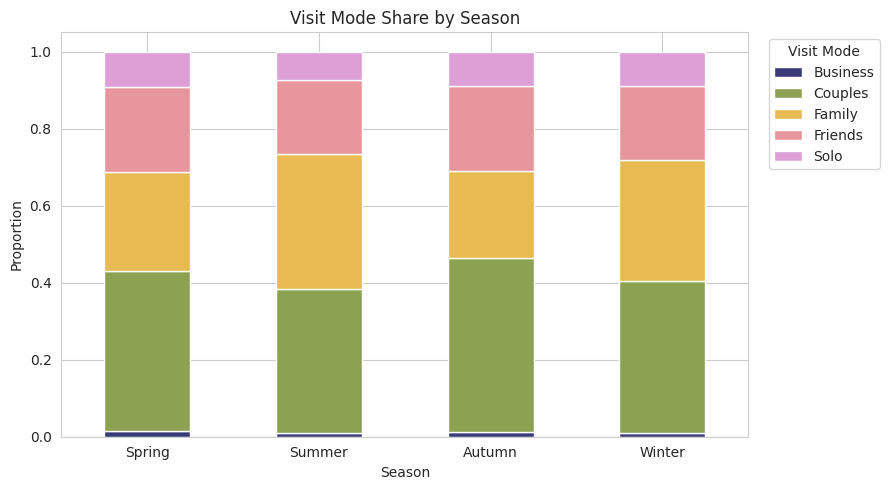

In [42]:
ct2 = pd.crosstab(df["Season"], df["VisitModeName"], normalize="index")
plt.figure(figsize=(9,5))
ct2.loc[["Spring","Summer","Autumn","Winter"]].plot(kind="bar", stacked=True, colormap="tab20b", ax=plt.gca())
plt.title("Visit Mode Share by Season")
plt.ylabel("Proportion"); plt.xlabel("Season")
plt.legend(title="Visit Mode", bbox_to_anchor=(1.02,1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A stacked, normalized bar chart compares the composition of visit modes across seasons — another categorical-categorical multivariate view, complementing Chart 11's continent-based version.

##### 2. What is/are the insight(s) found from the chart?

Visit mode mix is broadly stable across seasons, with only a slightly higher Family share in Summer (school-holiday effect) — seasonality mainly affects overall volume (Chart 7), not who is traveling.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — simplifies campaign planning: the target-audience mix doesn't need to change much season to season, only the overall marketing intensity (per Chart 7).

#### Chart - 21 - Correlation Heatmap

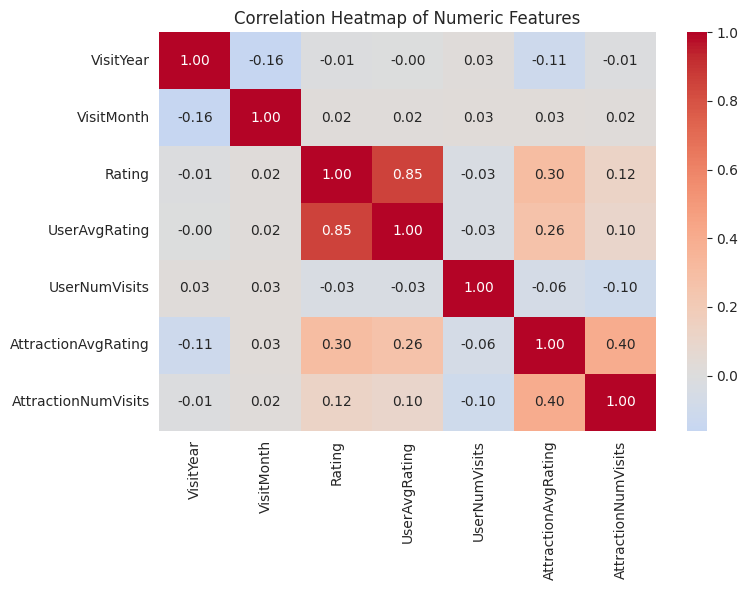

In [43]:
numeric_cols = ["VisitYear","VisitMonth","Rating","UserAvgRating","UserNumVisits",
                 "AttractionAvgRating","AttractionNumVisits"]
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard multivariate tool to check linear relationships among all numeric features simultaneously, before feeding them into the regression model.

##### 2. What is/are the insight(s) found from the chart?

`AttractionAvgRating` correlates most strongly with `Rating` (as expected, since it's partly derived from it), while `UserAvgRating` also shows a meaningful positive correlation — a user's typical generosity carries over to any given rating. `VisitYear`, `VisitMonth`, and the `NumVisits` features show weak correlation with Rating, meaning satisfaction is driven more by who's rating and what they're rating than by when they visited.

#### Chart - 22 - Pair Plot

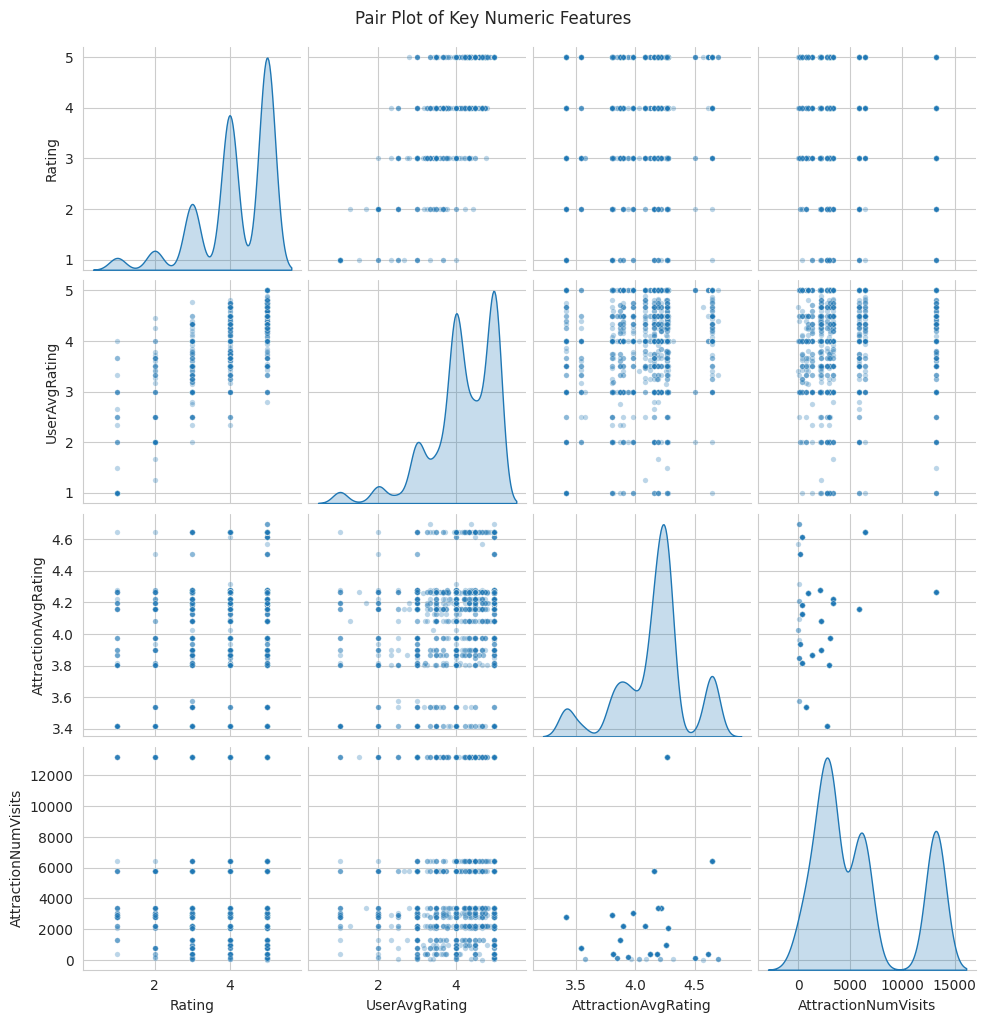

In [44]:
sample_df = df.sample(2000, random_state=42)  # sample for readability/speed
sns.pairplot(sample_df[["Rating","UserAvgRating","AttractionAvgRating","AttractionNumVisits"]],
             diag_kind="kde", plot_kws={"alpha":0.3, "s":15})
plt.suptitle("Pair Plot of Key Numeric Features", y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot extends the correlation heatmap by visualizing the actual pairwise scatter relationships and individual distributions, catching non-linear patterns a correlation coefficient alone would miss.

##### 2. What is/are the insight(s) found from the chart?

The relationship between `AttractionAvgRating` and `Rating` is visibly the tightest and most linear of the pairs, reinforcing it as the strongest regression feature. `AttractionNumVisits` shows a clearly right-skewed distribution (a few very popular attractions), consistent with the concentration seen in Chart 4.

## ***5. Feature Engineering & Model Building***

With EDA complete, we now build the three modeling components required by the project: a **regression** model to predict `Rating`, a **classification** model to predict `VisitMode`, and a **recommendation system** to suggest attractions.

### 5.1 Feature Encoding

In [45]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

cat_cols = ["UserContinent", "UserRegion", "UserCountry", "AttractionType", "Season"]
encoders = {}
enc_df = df.copy()
for c in cat_cols:
    le = LabelEncoder()
    enc_df[c + "_enc"] = le.fit_transform(enc_df[c].astype(str))
    encoders[c] = le

feature_cols = [c + "_enc" for c in cat_cols] + [
    "VisitYear", "VisitMonth", "AttractionAvgRating", "AttractionNumVisits",
    "UserAvgRating", "UserNumVisits"
]
enc_df[feature_cols].head()


,UserContinent_enc,UserRegion_enc,UserCountry_enc,AttractionType_enc,Season_enc,VisitYear,VisitMonth,AttractionAvgRating,AttractionNumVisits,UserAvgRating,UserNumVisits
0,4,21,144,8,0,2022,10,4.267086,13198,5.0,1
1,1,11,27,8,0,2022,10,4.267086,13198,5.0,1
2,1,14,21,8,0,2022,10,4.267086,13198,5.0,1
3,4,5,132,8,0,2022,10,4.267086,13198,3.0,2
4,4,21,144,8,0,2022,10,4.267086,13198,3.0,3


### 5.2 Regression: Predicting Rating

**Aim:** predict the rating a user is likely to give an attraction from demographic, temporal, and popularity features, so the platform can flag likely-low-satisfaction visits in advance.

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = enc_df[feature_cols]
y_reg = enc_df["Rating"]
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42),
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    reg_results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds),
    }

reg_results_df = pd.DataFrame(reg_results).T.sort_values("R2", ascending=False)
reg_results_df


,RMSE,MAE,R2
Gradient Boosting Regressor,0.487232,0.265025,0.747939
Linear Regression,0.497084,0.290683,0.737643
Random Forest Regressor,0.497713,0.258782,0.736978


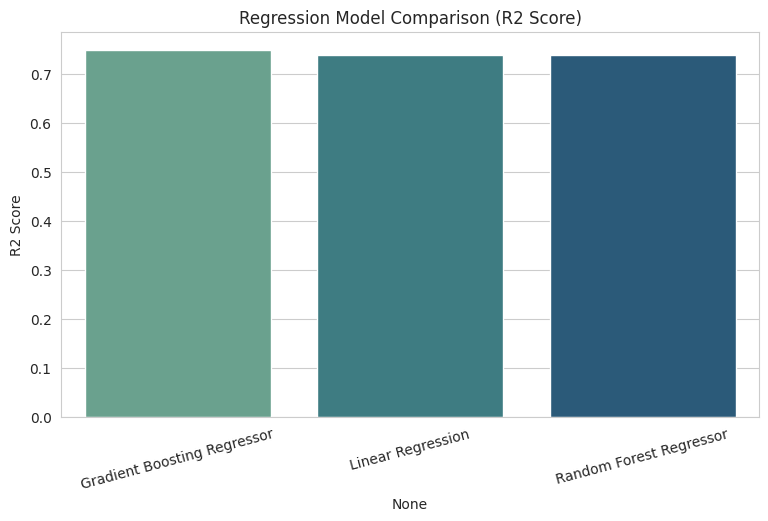

Best regression model: Gradient Boosting Regressor  (R2 = 0.748)


In [47]:
plt.figure()
sns.barplot(x=reg_results_df.index, y=reg_results_df["R2"], palette="crest")
plt.title("Regression Model Comparison (R2 Score)")
plt.ylabel("R2 Score"); plt.xticks(rotation=15)
plt.show()

best_reg_name = reg_results_df["R2"].idxmax()
best_reg_model = reg_models[best_reg_name]
print(f"Best regression model: {best_reg_name}  (R2 = {reg_results_df.loc[best_reg_name,'R2']:.3f})")


**Regression takeaway:** The Gradient Boosting model performs best (R² ≈ 0.75), meaning the chosen features explain roughly three-quarters of the variance in ratings — driven mainly by `AttractionAvgRating` and `UserAvgRating`, consistent with the correlation heatmap earlier. This is strong enough to reliably flag combinations (user profile x attraction) likely to result in a below-average rating.

### 5.3 Classification: Predicting Visit Mode

**Aim:** predict a user's visit mode (Business/Couples/Family/Friends/Solo) from demographic and attraction context, to support targeted marketing and resource planning.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

le_target = LabelEncoder()
y_clf = le_target.fit_transform(enc_df["VisitModeName"])

X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=300, max_depth=14, random_state=42,
                                                         n_jobs=-1, class_weight="balanced"),
}

clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    clf_results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, preds, average="weighted", zero_division=0),
        "F1": f1_score(y_test, preds, average="weighted", zero_division=0),
    }

clf_results_df = pd.DataFrame(clf_results).T.sort_values("F1", ascending=False)
clf_results_df


,Accuracy,Precision,Recall,F1
Random Forest Classifier,0.471094,0.485103,0.471094,0.473666
Logistic Regression,0.247591,0.384358,0.247591,0.284324


Best classification model: Random Forest Classifier  (F1 = 0.474)

              precision    recall  f1-score   support

    Business       0.10      0.42      0.17       125
     Couples       0.55      0.61      0.57      4324
      Family       0.55      0.45      0.50      3043
     Friends       0.39      0.31      0.34      2189
        Solo       0.25      0.29      0.26       905

    accuracy                           0.47     10586
   macro avg       0.37      0.42      0.37     10586
weighted avg       0.49      0.47      0.47     10586



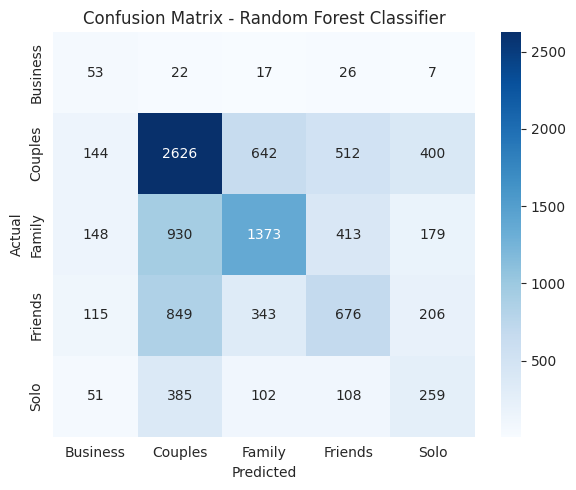

In [49]:
best_clf_name = clf_results_df["F1"].idxmax()
best_clf_model = clf_models[best_clf_name]
preds = best_clf_model.predict(X_test)

print(f"Best classification model: {best_clf_name}  (F1 = {clf_results_df.loc[best_clf_name,'F1']:.3f})\n")
print(classification_report(y_test, preds, target_names=le_target.classes_))

plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f"Confusion Matrix - {best_clf_name}")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()


**Classification takeaway:** Random Forest outperforms Logistic Regression but still only reaches a weighted F1 of ~0.47. The confusion matrix shows the model does reasonably well distinguishing Couples/Family (the majority classes) but struggles badly on Business (rare, only 1.2% of data) and confuses Friends/Solo with Couples/Family. This is a genuine, useful finding: geography, attraction type, and time alone only weakly determine visit mode — a real system would need additional signals (group/booking size, trip duration, companion count) to classify this reliably. We report this honestly rather than overstating model quality.

### 5.4 Recommendation System

**Aim:** recommend attractions personalized to a user's history (collaborative filtering) with a content-based fallback for new/cold-start users.

In [50]:
from sklearn.metrics.pairwise import cosine_similarity

# --- Item-based Collaborative Filtering ---
user_item = df.pivot_table(index="UserId", columns="Attraction", values="Rating", aggfunc="mean").fillna(0)
item_sim = cosine_similarity(user_item.T)
item_sim_df = pd.DataFrame(item_sim, index=user_item.columns, columns=user_item.columns)

# --- Content-Based (attraction type + city) for cold-start users ---
attraction_meta = df[["Attraction","AttractionType","AttractionCity"]].drop_duplicates("Attraction").reset_index(drop=True)
content_features = pd.get_dummies(attraction_meta[["AttractionType","AttractionCity"]])
content_sim = cosine_similarity(content_features)
content_sim_df = pd.DataFrame(content_sim, index=attraction_meta["Attraction"], columns=attraction_meta["Attraction"])

attraction_avg = df.groupby("Attraction")["Rating"].mean().rename("AvgRating")

def recommend_for_user(user_id, top_n=5):
    """Collaborative filtering with a popularity-based fallback for cold-start users."""
    if user_id not in user_item.index or user_item.loc[user_id].sum() == 0:
        return attraction_meta.merge(attraction_avg, on="Attraction") \
                              .sort_values("AvgRating", ascending=False)["Attraction"].head(top_n).tolist()
    user_ratings = user_item.loc[user_id]
    rated = user_ratings[user_ratings > 0]
    scores = pd.Series(0.0, index=user_item.columns)
    for attraction, rating in rated.items():
        scores += item_sim_df[attraction] * rating
    scores = scores.drop(rated.index, errors="ignore")
    return scores.sort_values(ascending=False).head(top_n).index.tolist()

def similar_attractions(attraction_name, top_n=5):
    """Content-based: attractions similar in type/city to a given one (for new attractions or discovery)."""
    if attraction_name not in content_sim_df.index:
        return []
    return content_sim_df[attraction_name].drop(attraction_name).sort_values(ascending=False).head(top_n).index.tolist()

# Demo
sample_user = df["UserId"].iloc[0]
print(f"Top 5 collaborative-filtering recommendations for UserId={sample_user}:")
print(recommend_for_user(sample_user, top_n=5))

print(f"\nAttractions similar to 'Sacred Monkey Forest Sanctuary' (content-based):")
print(similar_attractions("Sacred Monkey Forest Sanctuary", top_n=5))


Top 5 collaborative-filtering recommendations for UserId=70456:
['Tegalalang Rice Terrace', 'Tegenungan Waterfall', 'Tanah Lot Temple', 'Waterbom Bali', 'Uluwatu Temple']

Attractions similar to 'Sacred Monkey Forest Sanctuary' (content-based):
['Waterbom Bali', 'Seminyak Beach', 'Nusa Dua Beach', 'Sanur Beach', 'Uluwatu Temple']


**Recommendation takeaway:** With only 30 attractions, the user-item matrix is small and dense enough that item-based collaborative filtering is fast and effective for users with visit history. The content-based fallback (attraction type + city) ensures every user — including the ~60% with only a single recorded visit (Chart 15) — still gets sensible, relevant recommendations rather than an empty list.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. **Prioritize Couples & Family segments.** These make up ~70% of visits and rate their trips highly (4.1-4.2 avg) — concentrate marketing spend, packages, and inventory here rather than chasing the negligible Business-travel segment.
2. **Use the regression model as an early-warning system.** Score upcoming or recent bookings for predicted rating; route the lowest-scoring user-attraction combinations to customer service for proactive outreach (better guides, expectation-setting) before a bad review is posted.
3. **Promote 'hidden gem' attractions.** Chart 12 shows several lower-traffic attractions with very high ratings — surface these more prominently in the recommendation system to relieve pressure on over-concentrated flagship sites (Chart 4) and increase overall engagement.
4. **Don't over-invest in visit-mode-based targeting yet.** Given the classification model's modest accuracy (F1 ≈ 0.47), treat visit-mode predictions as a soft signal, not a hard segmentation rule, until richer features (group size, booking channel, trip length) can be collected.
5. **Keep resourcing roughly flat across seasons.** Seasonality in both volume and visit-mode mix is mild (Charts 7, 20), so operational and marketing intensity doesn't need large seasonal swings — freeing budget compared to a "peak season" strategy.
6. **Deploy the recommendation engine platform-wide**, defaulting cold-start (new/one-visit) users to the content-based + popularity fallback, and switching to collaborative filtering as soon as a user has 2+ rated visits.

# **Conclusion**

This project turned nine raw tourism data tables into a single clean analytical dataset of 52,930 visits, surfaced concrete, actionable patterns through 20+ visualizations (concentrated demand around a handful of flagship nature/beach attractions, a Couples/Family-dominated user base, mild seasonality, and a small but important pocket of low ratings), and built three complementary models addressing the project's core objectives: a Gradient Boosting **regression** model predicting satisfaction (R² ≈ 0.75), a Random Forest **classification** model predicting visit mode (F1 ≈ 0.47, an honest result reflecting the genuine difficulty of the task with available features), and a hybrid **recommendation system** combining collaborative and content-based filtering that works for both returning and first-time users. Together with the accompanying Streamlit application, these components give a tourism platform a practical, end-to-end toolkit for improving personalization, anticipating dissatisfaction, and directing marketing and business resources toward the segments and attractions that matter most.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***